演習問題1

In [1]:
import pandas as pd
df = pd.read_excel('icecoffee.xlsx')
df.head()

,temperature,price,icecoffee
0,30,150,76
1,28,200,61
2,33,100,92
3,31,100,84
4,25,200,59


In [6]:
x = df[['temperature']]
y = df['icecoffee']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size = 0.7, test_size = 0.3, random_state = 0)

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print('intercept = ', model.intercept_)
print(pd.DataFrame({"Name":x_train.columns, "Coefficients":model.coef_}).sort_values(by='Coefficients'))

intercept =  -62.92592592592594
          Name  Coefficients
0  temperature      4.611111


In [10]:
from sklearn.metrics import r2_score
print('r^2 (train):',r2_score(y_train, model.predict(x_train)))
print('r^2 (test):',r2_score(y_test, model.predict(x_test)))

r^2 (train): 0.8517556874381802
r^2 (test): 0.813789151392553


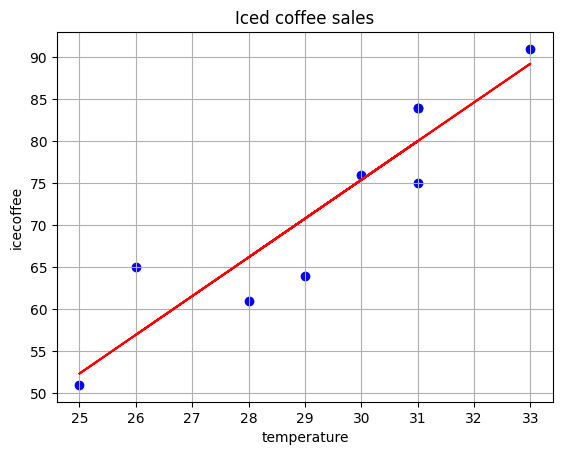

In [9]:
import matplotlib.pyplot as plt

plt.scatter(x_train, y_train, color = 'blue')
plt.plot(x_train, model.predict(x_train), color = 'red')
plt.title('Iced coffee sales')
plt.xlabel('temperature')
plt.ylabel('icecoffee')
plt.grid()
plt.show()

気温が高い時の方がアイスコーヒーはよく売れることが分かる

演習問題2

In [11]:
x = df.drop('icecoffee', axis = 1) # 売れた杯数を除いたすべての列の説明変数
y = df['icecoffee']

from sklearn.preprocessing import StandardScaler # 標準化を行うための機能

scaler = StandardScaler()
scaler.fit(x)
x_std = scaler.transform(x)
x_std = pd.DataFrame(x_std)
x_std.columns = x.columns

x_train, x_test, y_train, y_test = train_test_split(
    x_std, y, train_size = 0.7, test_size = 0.3, random_state = 0)

In [12]:
model = LinearRegression()
model.fit(x_train, y_train)
print('intercept =', model.intercept_)
print(pd.DataFrame({"Name":x_train.columns,"Coefficients":model.coef_}).sort_values(by='Coefficients'))

intercept = 71.98008749434304
          Name  Coefficients
1        price     -7.050295
0  temperature      6.530067


1杯あたりの値段が上がると売り上げが下がり、気温が上がると売り上げが上がる

In [13]:
print('r^2 (train):',r2_score(y_train, model.predict(x_train)))
print('r^2 (test):',r2_score(y_test, model.predict(x_test)))

r^2 (train): 0.9376274914692344
r^2 (test): 0.8947042757603103
